In [1]:
from xaikd import models, datasets, utils

from matplotlib import pyplot as plt

from torchvision import transforms as T
import numpy as np
import torch
from torch.nn import functional as F

from tqdm import tqdm

from torchvision.datasets import CelebA

In [2]:
DEVICE = utils.get_device()


In [3]:

LIST_ATTRS = "5_o_Clock_Shadow Arched_Eyebrows Attractive Bags_Under_Eyes Bald Bangs Big_Lips Big_Nose Black_Hair Blond_Hair Blurry Brown_Hair Bushy_Eyebrows Chubby Double_Chin Eyeglasses Goatee Gray_Hair Heavy_Makeup High_Cheekbones Male Mouth_Slightly_Open Mustache Narrow_Eyes No_Beard Oval_Face Pale_Skin Pointy_Nose Receding_Hairline Rosy_Cheeks Sideburns Smiling Straight_Hair Wavy_Hair Wearing_Earrings Wearing_Hat Wearing_Lipstick Wearing_Necklace Wearing_Necktie Young"
LIST_ATTRS = LIST_ATTRS.split(" ")

for a in LIST_ATTRS:
    print(f"> {a}")

> 5_o_Clock_Shadow
> Arched_Eyebrows
> Attractive
> Bags_Under_Eyes
> Bald
> Bangs
> Big_Lips
> Big_Nose
> Black_Hair
> Blond_Hair
> Blurry
> Brown_Hair
> Bushy_Eyebrows
> Chubby
> Double_Chin
> Eyeglasses
> Goatee
> Gray_Hair
> Heavy_Makeup
> High_Cheekbones
> Male
> Mouth_Slightly_Open
> Mustache
> Narrow_Eyes
> No_Beard
> Oval_Face
> Pale_Skin
> Pointy_Nose
> Receding_Hairline
> Rosy_Cheeks
> Sideburns
> Smiling
> Straight_Hair
> Wavy_Hair
> Wearing_Earrings
> Wearing_Hat
> Wearing_Lipstick
> Wearing_Necklace
> Wearing_Necktie
> Young


In [4]:
ATTR_NAME = "Bags_Under_Eyes"
ATTR = LIST_ATTRS.index(ATTR_NAME)
ATTR_NAME, ATTR

('Bags_Under_Eyes', 3)

In [5]:
model = models.get_trained_model("celeba-resnet18-pretrained")
assert not model.training 

model.to(DEVICE);

In [6]:
dataset = datasets.construct(f"celeba-attr{ATTR}")

In [7]:
ds_train = dataset.create_subset(train_split=True)

# input_transform = ds_train.transform

# ds_train.transform = None

In [8]:
ds_train.transform

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [9]:
def inverse_transform(x):
    mean = np.array([0.485, 0.456, 0.406]).reshape((1, 1, -1))
    std = np.array([0.229, 0.224, 0.225]).reshape((1, 1, -1))
    # print(x.shape)
    x = torch.permute(x.squeeze(0), (1, 2, 0)).detach().cpu().numpy()
    
    x =  x * std + mean
    return np.clip(x, a_min=0, a_max=1)

In [10]:
transform_norm = T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

In [11]:
F.one_hot?

Docstring:
one_hot(tensor, num_classes=-1) -> LongTensor

Takes LongTensor with index values of shape ``(*)`` and returns a tensor
of shape ``(*, num_classes)`` that have zeros everywhere except where the
index of last dimension matches the corresponding value of the input tensor,
in which case it will be 1.

See also `One-hot on Wikipedia`_ .

.. _One-hot on Wikipedia:
    https://en.wikipedia.org/wiki/One-hot

Arguments:
    tensor (LongTensor): class values of any shape.
    num_classes (int):  Total number of classes. If set to -1, the number
        of classes will be inferred as one greater than the largest class
        value in the input tensor.

Returns:
    LongTensor that has one more dimension with 1 values at the
    index of last dimension indicated by the input, and 0 everywhere
    else.

Examples:
    >>> F.one_hot(torch.arange(0, 5) % 3)
    tensor([[1, 0, 0],
            [0, 1, 0],
            [0, 0, 1],
            [1, 0, 0],
            [0, 1, 0]])
    >>> F.one_ho

100%|██████████████████████████████████████████████████████████████████████████████| 2544/2544 [01:32<00:00, 27.46it/s]


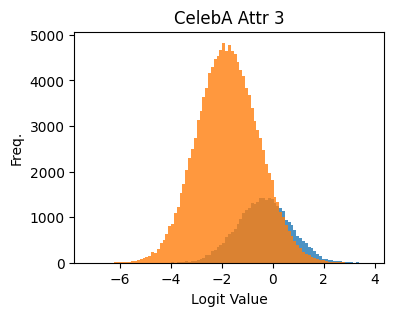

In [12]:
def logits_hist(attr_ix):

    arr_logit = []
    arr_label = []
    for x, y in tqdm(datasets.build_dataloader(ds_train, shuffle=False)):
        x = x.to(DEVICE)
        logits = model(x)[:, attr_ix]
        arr_logit.extend(logits.detach().cpu().numpy().tolist())
        arr_label.extend(y.numpy().tolist())

    arr_label = np.array(arr_label)
    arr_logit = np.array(arr_logit)
    
    bins = np.linspace(np.min(arr_logit), np.max(arr_logit), 100)
    plt.figure(figsize=(4, 3))
    
    plt.title(f"CelebA Attr {attr_ix}")
    plt.ylabel("Freq.")
    plt.xlabel("Logit Value")
    for target in [1, 0]:
        plt.hist(
            arr_logit[arr_label==target],
            bins=bins,
            label=f"label={target}",
            alpha=0.8
        )
    return arr_logit, arr_label
arr_logit, arr_label = logits_hist(ATTR)

In [13]:
from zennit.composites import Composite
from zennit.canonizers import Canonizer
from zennit.torchvision import ResNetCanonizer
from zennit.composites import EpsilonGammaBox
from zennit.attribution import Gradient

def get_heatmaps(model, data, attr_ix=ATTR):
    # use the ResNet-specific canonizer
    canonizer = ResNetCanonizer()
    
    # the ZBox rule needs the lowest and highest values, which are here for
    # ImageNet 0. and 1. with a different normalization for each channel
    low, high = transform_norm(torch.tensor([[[[[0.]]] * 3], [[[[1.]]] * 3]]))
    
    # create a composite, specifying the canonizers, if any
    composite = EpsilonGammaBox(low=low, high=high, canonizers=[canonizer])

    def attr_output(output):
        bs, _ = output.shape
        
        attr_vectors = F.one_hot(
            torch.tensor([attr_ix]*bs), 
            num_classes=40
        ).to(output.device)
        return output * attr_vectors
    
    target = torch.eye(40)[[attr_ix]].to(DEVICE)
    
    # create the attributor, specifying model and composite
    with Gradient(model=model, composite=composite) as attributor:
        # compute the model output and attribution
        output, attribution = attributor(data, attr_output)

    output = output.detach().cpu().numpy()[:, attr_ix]
    attribution = attribution.sum(dim=1).detach().cpu().numpy()
    
    return output, attribution
    
get_heatmaps(
    model=model,
    data=next(iter(datasets.build_dataloader(ds_train, shuffle=False)))[0].to(DEVICE),
);

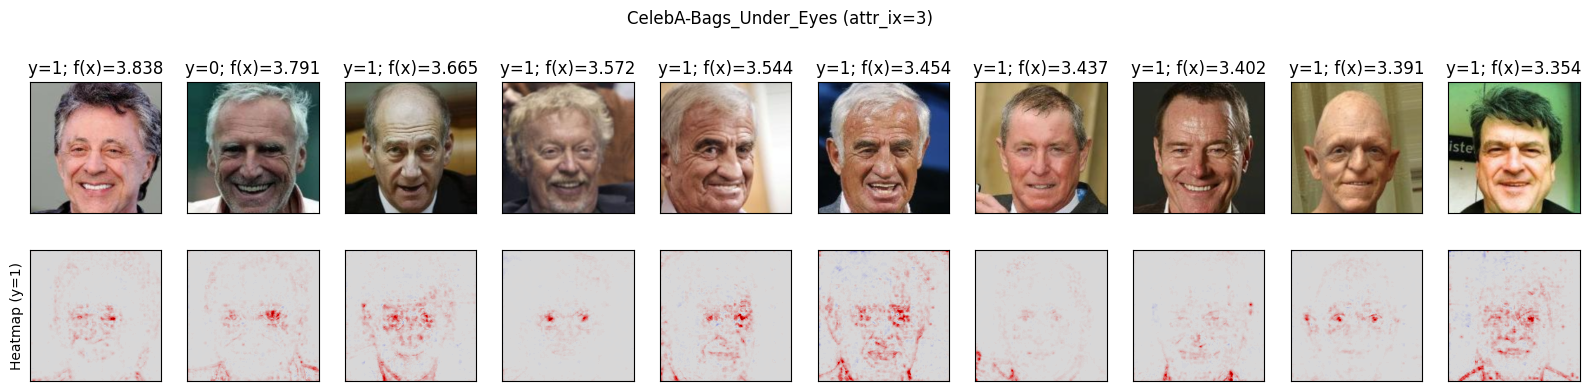

In [14]:
from matplotlib.colors import ListedColormap

def viz_heatmap(
    heatmap,
):

    assert len(heatmap.shape) == 2
    
    b = np.abs(heatmap).max()

    my_cmap = plt.cm.seismic(np.arange(plt.cm.seismic.N))
    my_cmap[:, 0:3] *= 0.85
    my_cmap = ListedColormap(my_cmap)

    sum_Ri = np.sum(heatmap)
 
    plt.axis("on")
    plt.xticks([])
    plt.yticks([])
    plt.imshow(heatmap, cmap=my_cmap, vmin=-b, vmax=b)

def ano():

    ncols = 10
    nrows = 2

    torch.manual_seed(1)
    # dl = datasets.build_dataloader(ds_train, batch_size=100, shuffle=True)
    # X, y = next(iter(dl))

    # output, heatmaps = get_heatmaps(model=model, data=X.to(DEVICE))
    
    plt.figure(figsize=(2*ncols, 2*nrows))
    plt.suptitle(f"CelebA-{ATTR_NAME} (attr_ix={ATTR})", y=1.05)

    count = 0
    indices = np.argsort(-arr_logit)
    label = 1
    
    selected_indices = indices[:ncols]
    
    for dix in selected_indices:
        x, y = ds_train[dix]
        ts_x = x.to(DEVICE).unsqueeze(0)
        
        fx, heatmap = get_heatmaps(
            model=model, 
            data=ts_x
        )
        heatmap = heatmap.squeeze(0)            
        
        fx = float(fx.squeeze())
        plt.subplot(nrows, ncols, count+1)
        
        plt.title(f"y={int(y)}; f(x)={fx:.3f}")
        plt.imshow(inverse_transform(x))
        plt.xticks([]); plt.yticks([]);

        plt.subplot(nrows, ncols, ncols + count+1)
        viz_heatmap(heatmap)
        plt.xticks([]); plt.yticks([]);

        if count == 0:
            plt.ylabel("Heatmap (y=1)")
        count += 1
    
    
ano()